In [74]:
from IPython.display import display
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "last_expr"

L2: Error: 0.614
L1: Error: 0.125
L2: Error: 0.896
L1: Error: 0.215
L2: Error: 0.212
L1: Error: 0.081
L2: Error: 1.317
L1: Error: 0.371


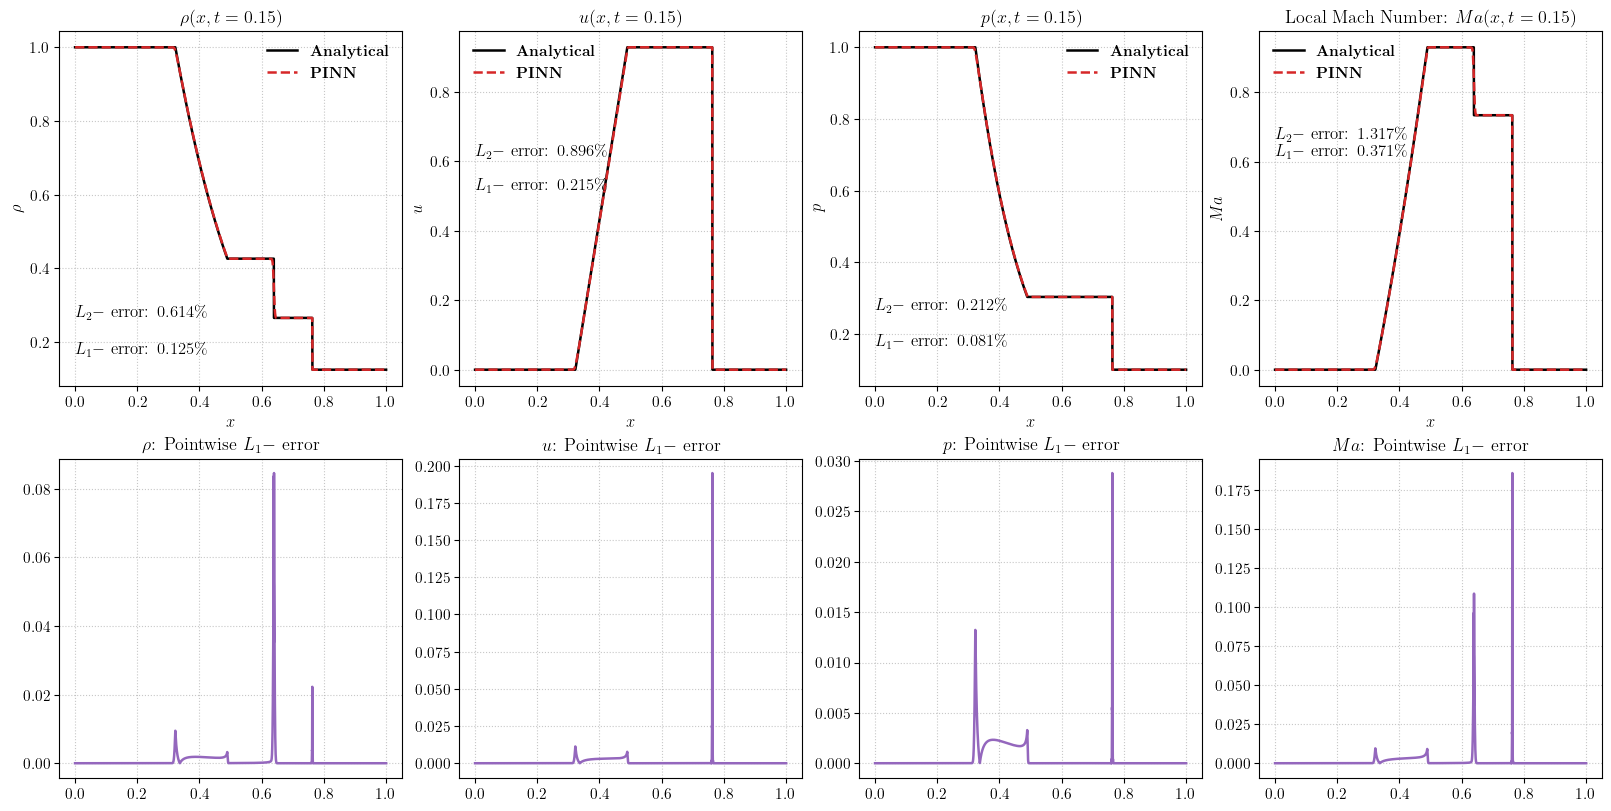

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
from scipy.interpolate import interp1d

# -------------------------
# Matplotlib styling
# -------------------------
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.grid": True,
    "grid.linestyle": ":",
    "grid.alpha": 0.7
})

def safe_legend(ax):
    h, l = ax.get_legend_handles_labels()
    if h:
        ax.legend(frameon=False)

# -------------------------
# Load data
# -------------------------
xy_star = np.load("xy_star.npy", allow_pickle=True)
uvp_star = np.load("uvp_pred.npy", allow_pickle=True)
x_pred = xy_star[:, 0]
r_pred = uvp_star[:, 0]
u_pred = uvp_star[:, 1]
p_pred = uvp_star[:, 2]
M_pred = u_pred/np.sqrt(1.4*p_pred/r_pred)
x_ana = np.load("x_ana.npy", allow_pickle=True)                                                                                 
r_ana = np.load("r_ana.npy", allow_pickle=True)                                                                                 
u_ana = np.load("u_ana.npy", allow_pickle=True)                                                                                 
p_ana = np.load("p_ana.npy", allow_pickle=True)  
M_ana = u_ana/np.sqrt(1.4*p_ana/r_ana)



# -------------------------
# Figure & GridSpec
# -------------------------
fig = plt.figure(figsize=(16, 8), constrained_layout=True)

# Main grid: 2 rows × 4 columns
gs = GridSpec(2, 4, figure=fig, height_ratios=[1, 0.9])

# ---- Top row (4 equal plots)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[0, 3])

# ---- Bottom row: span all columns, then subdivide into 3
#gs_bottom = gs[1, :].subgridspec(1, 4, wspace=0.35)

ax5 = fig.add_subplot(gs[1, 0])
ax6 = fig.add_subplot(gs[1, 1])
ax7 = fig.add_subplot(gs[1, 2])
ax8 = fig.add_subplot(gs[1, 3])

# -------------------------
# (a) PINN vs Analytical: \rho
# -------------------------
ax1.plot(x_ana, r_ana, "-", lw=1.8, color="black", label=r"\textbf{Analytical}")
ax1.plot(x_pred, r_pred, "--", lw=1.8, color="tab:red", label=r"\textbf{PINN}")
ax1.set_title(r"$\rho(x,t=0.15)$")
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$\rho$")
safe_legend(ax1)

# -------------------------
# (b) (a) PINN vs Analytical: u
# -------------------------
ax2.plot(x_ana, u_ana, "-", lw=1.8, color="black", label=r"\textbf{Analytical}")
ax2.plot(x_pred, u_pred, "--", lw=1.8, color="tab:red", label=r"\textbf{PINN}")

ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$u$")
ax2.set_title(r"$u(x,t=0.15)$")
safe_legend(ax2)

# -------------------------
# (c) PINN vs Analytical: p
# -------------------------
ax3.plot(x_ana, p_ana, "-", lw=1.8, color="black", label=r"\textbf{Analytical}")
ax3.plot(x_pred, p_pred, "--", lw=1.8, color="tab:red", label=r"\textbf{PINN}")
ax3.set_title(r"$p(x,t=0.15)$")
ax3.set_xlabel(r"$x$")
ax3.set_ylabel(r"$p$")
safe_legend(ax3)



# -------------------------
# (d) PINN vs Analytical: Ma
# -------------------------
ax4.plot(x_ana, M_ana, "-", lw=1.8, color="black", label=r"\textbf{Analytical}")
ax4.plot(x_pred, M_pred, "--", lw=1.8, color="tab:red", label=r"\textbf{PINN}")

ax4.set_xlabel(r"$x$")
ax4.set_ylabel(r"$Ma$")
ax4.set_title(r"Local Mach Number: $Ma(x,t=0.15)$")
safe_legend(ax4)


# -------------------------
# (d) All methods
# -------------------------
# ax4.plot(x_ref, u_ref, "--", lw=1.5, color="tab:blue", label=r"\textbf{DGSEM}")
# ax4.plot(x, u_p, lw=1.8, color="tab:red", label=r"\textbf{PINN}")
# ax4.plot(data_weno[:, 0], data_weno[:, 1], "--", lw=1.5,
#          color="tab:green", label=r"\textbf{WENO}")
# ax4.plot(x_ana, u_ana, "--", lw=1.5, color="black",
#          label=r"\textbf{Analytical}")
# ax4.set_xlim([-0.02, 0.02])
# ax4.set_title(r"All methods in shock region")
# safe_legend(ax4)
# ax1.set_xlabel(r"$x$")
# ax1.set_ylabel(r"$u$")
# ax2.set_xlabel(r"$x$")
# ax2.set_ylabel(r"$u$")
# ax3.set_xlabel(r"$x$")
# ax3.set_ylabel(r"$u$")
# ax4.set_xlabel(r"$x$")
# ax4.set_ylabel(r"$u$")

# # -------------------------
# # Bottom row: pointwise L1 errors
# # -------------------------
ax5.plot(x_pred, np.abs(r_pred - interp1d(x_ana, r_ana, kind="cubic")(x_pred)),
         lw=1.8, color="tab:purple")
ax5.set_title(r"$\rho$: Pointwise $L_1-$ error")

ax6.plot(x_pred, np.abs(u_pred - interp1d(x_ana, u_ana, kind="cubic")(x_pred)),
         lw=1.8, color="tab:purple")
ax6.set_title(r"$u$: Pointwise $L_1-$ error")

ax7.plot(x_pred, np.abs(p_pred - interp1d(x_ana, p_ana, kind="cubic")(x_pred)),
         lw=1.8, color="tab:purple")
ax7.set_title(r"$p$: Pointwise $L_1-$ error")

ax8.plot(x_pred, np.abs(M_pred - interp1d(x_ana, M_ana, kind="cubic")(x_pred)),
         lw=1.8, color="tab:purple")
ax8.set_title(r"$Ma$: Pointwise $L_1-$ error")



# ###### Error layout---
# #Compute Error DG: 
from scipy.interpolate import interp1d 


# Rho
f_cubic = interp1d(x_ana, r_ana, kind='cubic') 
y_cubic = f_cubic(x_pred) 
err_l2_ana = np.linalg.norm(y_cubic - r_pred)/np.linalg.norm(y_cubic) 
err_l1_ana = np.linalg.norm(y_cubic - r_pred, ord=1) / np.linalg.norm(y_cubic, ord=1) 
err_l2_str_r = str(np.round(100*err_l2_ana, 3)) 
err_l1_str_r = str(np.round(100*err_l1_ana, 3)) 
print(f"L2: Error: {err_l2_str_r}")
print(f"L1: Error: {err_l1_str_r}") 

# u
f_cubic = interp1d(x_ana, u_ana, kind='cubic') 
y_cubic = f_cubic(x_pred) 
err_l2_ana = np.linalg.norm(y_cubic - u_pred)/np.linalg.norm(y_cubic) 
err_l1_ana = np.linalg.norm(y_cubic - u_pred, ord=1) / np.linalg.norm(y_cubic, ord=1) 
err_l2_str_u = str(np.round(100*err_l2_ana, 3)) 
err_l1_str_u = str(np.round(100*err_l1_ana, 3)) 
print(f"L2: Error: {err_l2_str_u}")
print(f"L1: Error: {err_l1_str_u}") 


# p
f_cubic = interp1d(x_ana, p_ana, kind='cubic') 
y_cubic = f_cubic(x_pred) 
err_l2_ana = np.linalg.norm(y_cubic - p_pred)/np.linalg.norm(y_cubic) 
err_l1_ana = np.linalg.norm(y_cubic - p_pred, ord=1) / np.linalg.norm(y_cubic, ord=1) 
err_l2_str_p = str(np.round(100*err_l2_ana, 3)) 
err_l1_str_p = str(np.round(100*err_l1_ana, 3)) 
print(f"L2: Error: {err_l2_str_p}")
print(f"L1: Error: {err_l1_str_p}")


# Ma
f_cubic = interp1d(x_ana, M_ana, kind='cubic') 
y_cubic = f_cubic(x_pred) 
err_l2_ana = np.linalg.norm(y_cubic - M_pred)/np.linalg.norm(y_cubic) 
err_l1_ana = np.linalg.norm(y_cubic - M_pred, ord=1) / np.linalg.norm(y_cubic, ord=1) 
err_l2_str_M = str(np.round(100*err_l2_ana, 3)) 
err_l1_str_M = str(np.round(100*err_l1_ana, 3)) 
print(f"L2: Error: {err_l2_str_M}")
print(f"L1: Error: {err_l1_str_M}")

ax1.text( 0.0, 0.3, r"$L_2-$ error: " + err_l2_str_r + "\%", fontsize=12, verticalalignment="top" ) 
ax1.text( 0.0, 0.2, r"$L_1-$ error: " + err_l1_str_r + "\%", fontsize=12, verticalalignment="top" ) 
ax2.text( 0.0, 0.65, r"$L_2-$ error: " + err_l2_str_u + "\%", fontsize=12, verticalalignment="top" ) 
ax2.text( 0.0, 0.55, r"$L_1-$ error: " + err_l1_str_u + "\%", fontsize=12, verticalalignment="top" ) 
ax3.text( 0.0, 0.3, r"$L_2-$ error: " + err_l2_str_p + "\%", fontsize=12, verticalalignment="top" ) 
ax3.text( 0.0, 0.2, r"$L_1-$ error: " + err_l1_str_p + "\%", fontsize=12, verticalalignment="top" )
ax4.text( 0.0, 0.70, r"$L_2-$ error: " + err_l2_str_M + "\%", fontsize=12, verticalalignment="top" ) 
ax4.text( 0.0, 0.65, r"$L_1-$ error: " + err_l1_str_M + "\%", fontsize=12, verticalalignment="top" )



# # -------------------------
# # Panel labels
# # -------------------------
# for ax, lab in zip([ax1,ax2,ax3,ax4,ax5,ax6,ax7],
#                    ['(a)','(b)','(c)','(d)','(e)','(f)','(g)']):
#     ax.text(0.02, 0.95, lab, transform=ax.transAxes,
#             fontsize=13, fontweight="bold", va="top")

plt.savefig("Euler_Analytical.png", dpi=300, bbox_inches="tight")
plt.savefig("Euler_Analytical.pdf", bbox_inches="tight")
plt.show()


In [4]:
d_weno = np.load("xrup_weno.npy", allow_pickle=True)

L2: Error: 0.349
L1: Error: 0.086
L2: Error: 0.684
L1: Error: 0.164
L2: Error: 0.167
L1: Error: 0.062
L2: Error: 0.836
L1: Error: 0.26


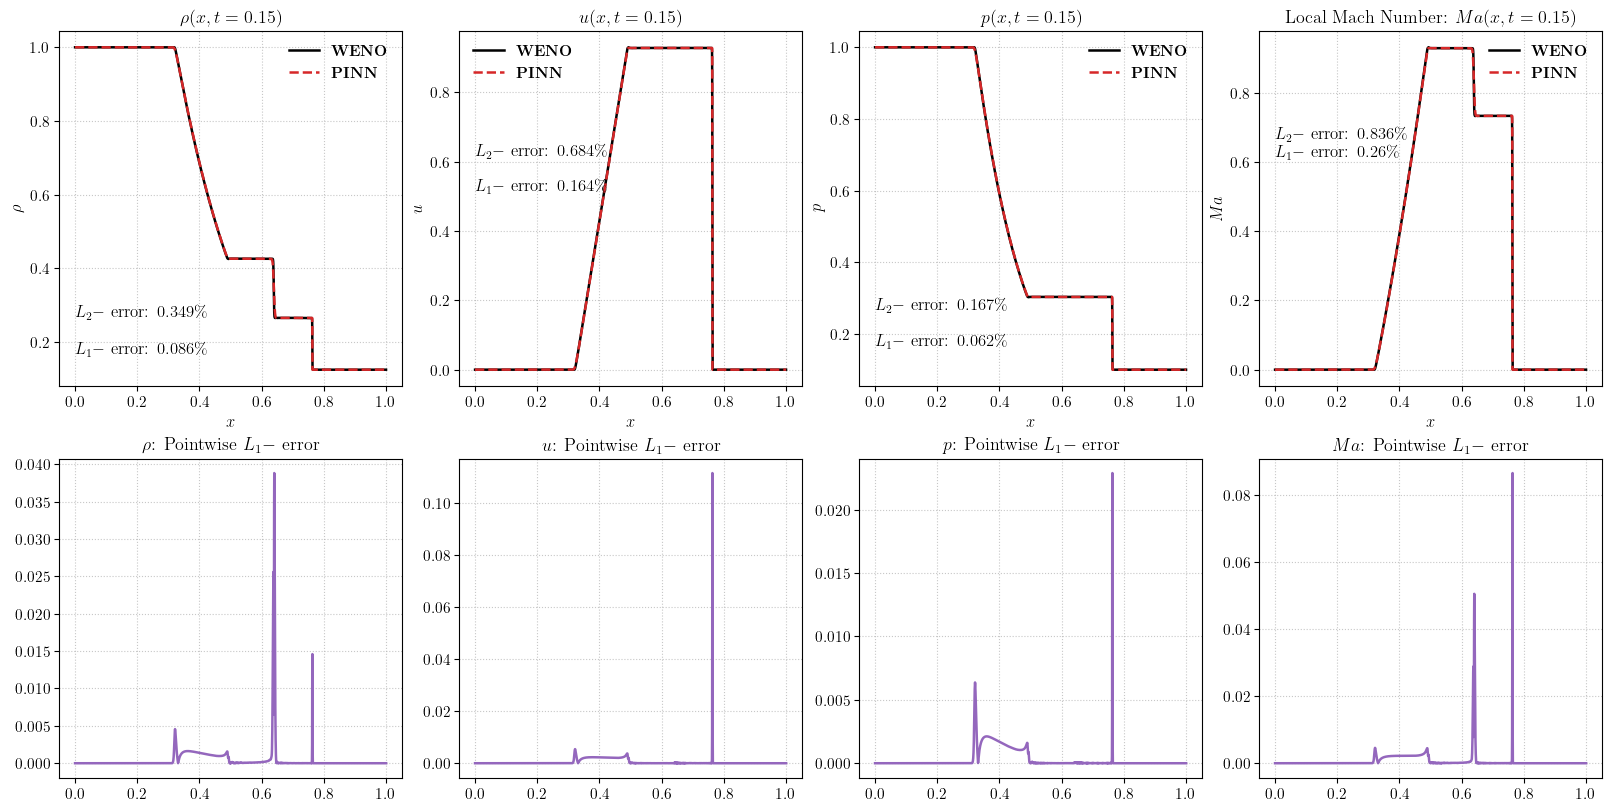

In [5]:
# -------------------------
# Matplotlib styling
# -------------------------
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.grid": True,
    "grid.linestyle": ":",
    "grid.alpha": 0.7
})

def safe_legend(ax):
    h, l = ax.get_legend_handles_labels()
    if h:
        ax.legend(frameon=False)

# -------------------------
# Load data
# -------------------------
xy_star = np.load("xy_star.npy", allow_pickle=True)
uvp_star = np.load("uvp_pred.npy", allow_pickle=True)
x_pred = xy_star[:, 0]
r_pred = uvp_star[:, 0]
u_pred = uvp_star[:, 1]
p_pred = uvp_star[:, 2]
M_pred = u_pred/np.sqrt(1.4*p_pred/r_pred)
x_ana = d_weno[:, 0]                                                                               
r_ana = d_weno[:, 1]                                                                               
u_ana = d_weno[:, 2]                                                                                  
p_ana = d_weno[:, 3]   
M_ana = u_ana/np.sqrt(1.4*p_ana/r_ana)



# -------------------------
# Figure & GridSpec
# -------------------------
fig = plt.figure(figsize=(16, 8), constrained_layout=True)

# Main grid: 2 rows × 4 columns
gs = GridSpec(2, 4, figure=fig, height_ratios=[1, 0.9])

# ---- Top row (4 equal plots)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[0, 3])

# ---- Bottom row: span all columns, then subdivide into 3
#gs_bottom = gs[1, :].subgridspec(1, 4, wspace=0.35)

ax5 = fig.add_subplot(gs[1, 0])
ax6 = fig.add_subplot(gs[1, 1])
ax7 = fig.add_subplot(gs[1, 2])
ax8 = fig.add_subplot(gs[1, 3])

# -------------------------
# (a) PINN vs Analytical: \rho
# -------------------------
ax1.plot(x_ana, r_ana, "-", lw=1.8, color="black", label=r"\textbf{WENO}")
ax1.plot(x_pred, r_pred, "--", lw=1.8, color="tab:red", label=r"\textbf{PINN}")
ax1.set_title(r"$\rho(x,t=0.15)$")
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$\rho$")
safe_legend(ax1)

# -------------------------
# (b) (a) PINN vs Analytical: u
# -------------------------
ax2.plot(x_ana, u_ana, "-", lw=1.8, color="black", label=r"\textbf{WENO}")
ax2.plot(x_pred, u_pred, "--", lw=1.8, color="tab:red", label=r"\textbf{PINN}")
ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$u$")
ax2.set_title(r"$u(x,t=0.15)$")
safe_legend(ax2)

# -------------------------
# (c) PINN vs Analytical: p
# -------------------------
ax3.plot(x_ana, p_ana, "-", lw=1.8, color="black", label=r"\textbf{WENO}")
ax3.plot(x_pred, p_pred, "--", lw=1.8, color="tab:red", label=r"\textbf{PINN}")
ax3.set_title(r"$p(x,t=0.15)$")
ax3.set_xlabel(r"$x$")
ax3.set_ylabel(r"$p$")
safe_legend(ax3)



# -------------------------
# (d) PINN vs Analytical: Ma
# -------------------------
ax4.plot(x_ana, M_ana, "-", lw=1.8, color="black", label=r"\textbf{WENO}")
ax4.plot(x_pred, M_pred, "--", lw=1.8, color="tab:red", label=r"\textbf{PINN}")
ax4.set_xlabel(r"$x$")
ax4.set_ylabel(r"$Ma$")
ax4.set_title(r"Local Mach Number: $Ma(x,t=0.15)$")
safe_legend(ax4)


# -------------------------
# (d) All methods
# -------------------------
# ax4.plot(x_ref, u_ref, "--", lw=1.5, color="tab:blue", label=r"\textbf{DGSEM}")
# ax4.plot(x, u_p, lw=1.8, color="tab:red", label=r"\textbf{PINN}")
# ax4.plot(data_weno[:, 0], data_weno[:, 1], "--", lw=1.5,
#          color="tab:green", label=r"\textbf{WENO}")
# ax4.plot(x_ana, u_ana, "--", lw=1.5, color="black",
#          label=r"\textbf{Analytical}")
# ax4.set_xlim([-0.02, 0.02])
# ax4.set_title(r"All methods in shock region")
# safe_legend(ax4)
# ax1.set_xlabel(r"$x$")
# ax1.set_ylabel(r"$u$")
# ax2.set_xlabel(r"$x$")
# ax2.set_ylabel(r"$u$")
# ax3.set_xlabel(r"$x$")
# ax3.set_ylabel(r"$u$")
# ax4.set_xlabel(r"$x$")
# ax4.set_ylabel(r"$u$")

# # -------------------------
# # Bottom row: pointwise L1 errors
# # -------------------------
ax5.plot(x_ana, np.abs(r_ana - interp1d(x_pred, r_pred, kind="cubic")(x_ana)),
         lw=1.8, color="tab:purple")
ax5.set_title(r"$\rho$: Pointwise $L_1-$ error")

ax6.plot(x_ana, np.abs(u_ana - interp1d(x_pred, u_pred, kind="cubic")(x_ana)),
         lw=1.8, color="tab:purple")
ax6.set_title(r"$u$: Pointwise $L_1-$ error")

ax7.plot(x_ana, np.abs(p_ana - interp1d(x_pred, p_pred, kind="cubic")(x_ana)),
         lw=1.8, color="tab:purple")
ax7.set_title(r"$p$: Pointwise $L_1-$ error")

ax8.plot(x_ana, np.abs(M_ana - interp1d(x_pred, M_pred, kind="cubic")(x_ana)),
         lw=1.8, color="tab:purple")
ax8.set_title(r"$Ma$: Pointwise $L_1-$ error")



# ###### Error layout---
# #Compute Error DG: 
from scipy.interpolate import interp1d 


# Rho
f_cubic = interp1d(x_pred, r_pred, kind='cubic') 
y_cubic = f_cubic(x_ana) 
err_l2_ana = np.linalg.norm(r_ana - y_cubic)/np.linalg.norm(r_ana) 
err_l1_ana = np.linalg.norm(r_ana - y_cubic, ord=1) / np.linalg.norm(r_ana, ord=1) 
err_l2_str_r = str(np.round(100*err_l2_ana, 3)) 
err_l1_str_r = str(np.round(100*err_l1_ana, 3)) 
print(f"L2: Error: {err_l2_str_r}")
print(f"L1: Error: {err_l1_str_r}") 

# u
f_cubic = interp1d(x_pred, u_pred, kind='cubic') 
y_cubic = f_cubic(x_ana) 
err_l2_ana = np.linalg.norm(u_ana - y_cubic)/np.linalg.norm(u_ana) 
err_l1_ana = np.linalg.norm(u_ana - y_cubic, ord=1) / np.linalg.norm(u_ana, ord=1) 
err_l2_str_u = str(np.round(100*err_l2_ana, 3)) 
err_l1_str_u = str(np.round(100*err_l1_ana, 3)) 
print(f"L2: Error: {err_l2_str_u}")
print(f"L1: Error: {err_l1_str_u}") 


# p
f_cubic = interp1d(x_pred, p_pred, kind='cubic') 
y_cubic = f_cubic(x_ana) 
err_l2_ana = np.linalg.norm(p_ana - y_cubic )/np.linalg.norm(p_ana) 
err_l1_ana = np.linalg.norm(p_ana - y_cubic, ord=1) / np.linalg.norm(p_ana, ord=1) 
err_l2_str_p = str(np.round(100*err_l2_ana, 3)) 
err_l1_str_p = str(np.round(100*err_l1_ana, 3)) 
print(f"L2: Error: {err_l2_str_p}")
print(f"L1: Error: {err_l1_str_p}")


# Ma
f_cubic = interp1d(x_pred, M_pred, kind='cubic') 
y_cubic = f_cubic(x_ana) 
err_l2_ana = np.linalg.norm(M_ana - y_cubic)/np.linalg.norm(M_ana) 
err_l1_ana = np.linalg.norm(M_ana - y_cubic, ord=1) / np.linalg.norm(M_ana, ord=1) 
err_l2_str_M = str(np.round(100*err_l2_ana, 3)) 
err_l1_str_M = str(np.round(100*err_l1_ana, 3)) 
print(f"L2: Error: {err_l2_str_M}")
print(f"L1: Error: {err_l1_str_M}")

ax1.text( 0.0, 0.3, r"$L_2-$ error: " + err_l2_str_r + "\%", fontsize=12, verticalalignment="top" ) 
ax1.text( 0.0, 0.2, r"$L_1-$ error: " + err_l1_str_r + "\%", fontsize=12, verticalalignment="top" ) 
ax2.text( 0.0, 0.65, r"$L_2-$ error: " + err_l2_str_u + "\%", fontsize=12, verticalalignment="top" ) 
ax2.text( 0.0, 0.55, r"$L_1-$ error: " + err_l1_str_u + "\%", fontsize=12, verticalalignment="top" ) 
ax3.text( 0.0, 0.3, r"$L_2-$ error: " + err_l2_str_p + "\%", fontsize=12, verticalalignment="top" ) 
ax3.text( 0.0, 0.2, r"$L_1-$ error: " + err_l1_str_p + "\%", fontsize=12, verticalalignment="top" )
ax4.text( 0.0, 0.70, r"$L_2-$ error: " + err_l2_str_M + "\%", fontsize=12, verticalalignment="top" ) 
ax4.text( 0.0, 0.65, r"$L_1-$ error: " + err_l1_str_M + "\%", fontsize=12, verticalalignment="top" )



# # -------------------------
# # Panel labels
# # -------------------------
# for ax, lab in zip([ax1,ax2,ax3,ax4,ax5,ax6,ax7],
#                    ['(a)','(b)','(c)','(d)','(e)','(f)','(g)']):
#     ax.text(0.02, 0.95, lab, transform=ax.transAxes,
#             fontsize=13, fontweight="bold", va="top")
plt.savefig("Euler_WENO.png", dpi=300, bbox_inches="tight")
plt.savefig("Euler_WENO.pdf", bbox_inches="tight")
plt.show()